In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

In [2]:
url = "https://raw.githubusercontent.com/alexeygrigorev/datasets/master/car_fuel_efficiency.csv"
df = pd.read_csv(url)
df.head(5)

,engine_displacement,num_cylinders,horsepower,vehicle_weight,acceleration,model_year,origin,fuel_type,drivetrain,num_doors,fuel_efficiency_mpg
0,170,3.0,159.0,3413.433759,17.7,2003,Europe,Gasoline,All-wheel drive,0.0,13.231729
1,130,5.0,97.0,3149.664934,17.8,2007,USA,Gasoline,Front-wheel drive,0.0,13.688217
2,170,NaN,78.0,3079.038997,15.1,2018,Europe,Gasoline,Front-wheel drive,0.0,14.246341
3,220,4.0,NaN,2542.392402,20.2,2009,USA,Diesel,All-wheel drive,2.0,16.912736
4,210,1.0,140.0,3460.870990,14.4,2009,Europe,Gasoline,All-wheel drive,2.0,12.488369


In [3]:
columns = ['engine_displacement', 'horsepower', 'vehicle_weight', 'model_year', 'fuel_efficiency_mpg']
df = df[columns]
df

,engine_displacement,horsepower,vehicle_weight,model_year,fuel_efficiency_mpg
0,170,159.0,3413.433759,2003,13.231729
1,130,97.0,3149.664934,2007,13.688217
2,170,78.0,3079.038997,2018,14.246341
3,220,NaN,2542.392402,2009,16.912736
4,210,140.0,3460.870990,2009,12.488369
...,...,...,...,...,...
9699,140,164.0,2981.107371,2013,15.101802
9700,180,154.0,2439.525729,2004,17.962326
9701,220,138.0,2583.471318,2008,17.186587
9702,230,177.0,2905.527390,2011,15.331551


#### Checking if the column has a long tail

<Axes: xlabel='fuel_efficiency_mpg', ylabel='Count'>

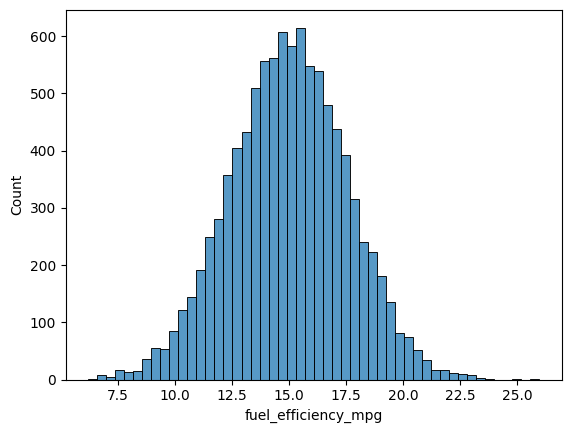

In [4]:
sns.histplot(df.fuel_efficiency_mpg, bins=50)

# Q1

In [5]:
df.isnull().sum()

engine_displacement      0
horsepower             708
vehicle_weight           0
model_year               0
fuel_efficiency_mpg      0
dtype: int64

# Q2

In [6]:
median = df.horsepower.median()
median

np.float64(149.0)

## Prepare and split the dataset
##### Shuffle the dataset (the filtered one you created above), use seed 42.
##### Split your data in train/val/test sets, with 60%/20%/20% distribution.

In [7]:
def shuffle_with_seed(seed, n):
    idx = np.arange(n)
    np.random.seed(seed)
    np.random.shuffle(idx)
    return idx

In [8]:
def prepare_dataset(df, seed, predictor_column):
    df = df.copy()
    n = len(df)
    n_val = int(n * 0.2)
    n_test = int(n * 0.2)
    n_train = n - n_val - n_test
    
    idx = shuffle_with_seed(seed, n)
    
    df_train = df.iloc[idx[:n_train]]
    df_val = df.iloc[idx[n_train: n_train + n_val]]
    df_test = df.iloc[idx[n_train + n_val:]]

    df_train = df_train.reset_index(drop=True)
    df_test = df_test.reset_index(drop=True)
    df_val = df_val.reset_index(drop=True)

    # No need to normalise as the predictor column doesn't have a long tail
    # y_train = np.log1p(df_train[predictor_column].values)
    # y_test = np.log1p(df_test[predictor_column].values)
    # y_val = np.log1p(df_val[predictor_column].values)
    
    y_train = df_train[predictor_column]
    y_test = df_test[predictor_column]
    y_val = df_val[predictor_column]

    del df_train[predictor_column]
    del df_test[predictor_column]
    del df_val[predictor_column]
    
    return df_train, df_val, df_test, y_train, y_test, y_val

In [9]:
df_train, df_val, df_test, y_train, y_test, y_val = prepare_dataset(df, 42, 'fuel_efficiency_mpg')

In [10]:
len(df), len(df_train), len(df_val), len(df_test)

(9704, 5824, 1940, 1940)

In [11]:
df_train.head()

,engine_displacement,horsepower,vehicle_weight,model_year
0,220,144.0,2535.887591,2009
1,160,141.0,2741.170484,2019
2,230,155.0,2471.880237,2017
3,150,206.0,3748.164469,2015
4,300,111.0,2135.716359,2006


In [12]:
df_val.head()

,engine_displacement,horsepower,vehicle_weight,model_year
0,180,112.0,2772.134410,2020
1,260,138.0,3014.061530,2022
2,140,181.0,3652.186151,2016
3,270,105.0,2753.040847,2023
4,170,224.0,4163.375137,2003


In [13]:
df_test.head()

,engine_displacement,horsepower,vehicle_weight,model_year
0,140,148.0,2704.826005,2017
1,210,136.0,3001.227490,2004
2,210,152.0,3747.467392,2021
3,190,128.0,2705.833636,2014
4,230,156.0,2505.939657,2005


# Q3

In [14]:
mean = df_train.horsepower.mean()

In [15]:
def fix_hp_missing_values(df, val):
    df = df.copy()
    df.horsepower = df.horsepower.fillna(val)
    return df

In [16]:
def prepare_X(df):
    df = df.copy()
    X = df.values
    return X

In [17]:
def train_linear_regression(X, y):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])
    XTX = np.dot(X.T, X)
    XTX_inv = np.linalg.inv(XTX)
    w_full = np.dot(XTX_inv, X.T)
    w_full = np.dot(w_full, y)
    return w_full[0], w_full[1:]

In [18]:
def rmse(y, y_pred):
    se = (y - y_pred) ** 2
    mse = se.mean()
    return round(np.sqrt(mse), 2)

#### Filling the missing horsepower column with 0

In [19]:
df_train_copy = fix_hp_missing_values(df_train, 0)
df_train_copy = prepare_X(df_train_copy)
w0, w = train_linear_regression(df_train_copy, y_train)

In [20]:
df_val_copy = fix_hp_missing_values(df_val, 0)
df_val_copy = prepare_X(df_val_copy)
y_pred = w0 + np.dot(df_val_copy, w)

In [21]:
rmse(y_val, y_pred)

np.float64(0.52)

<Axes: xlabel='fuel_efficiency_mpg', ylabel='Count'>

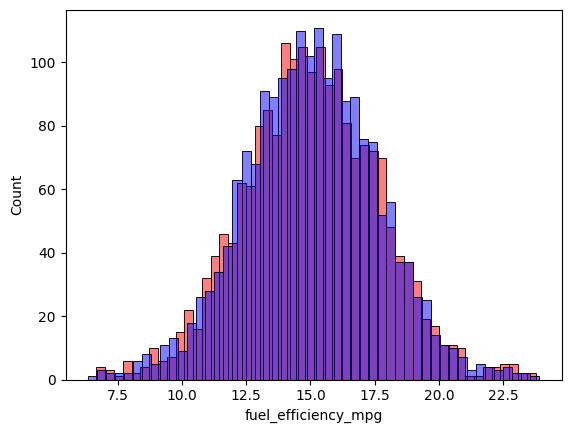

In [22]:
sns.histplot(y_val, color='red', bins=50, alpha=0.5)
sns.histplot(y_pred, color='blue', bins=50, alpha=0.5)

#### Filling the missing horsepower column with the mean

In [23]:
mean

np.float64(149.54476367006487)

In [24]:
df_train_copy = fix_hp_missing_values(df_train, mean)
df_train_copy = prepare_X(df_train_copy)
w0, w = train_linear_regression(df_train_copy, y_train)

In [25]:
df_val_copy = fix_hp_missing_values(df_val, mean)
df_val_copy = prepare_X(df_val_copy)
y_pred = w0 + np.dot(df_val_copy, w)
rmse(y_val, y_pred)

np.float64(0.46)

<Axes: xlabel='fuel_efficiency_mpg', ylabel='Count'>

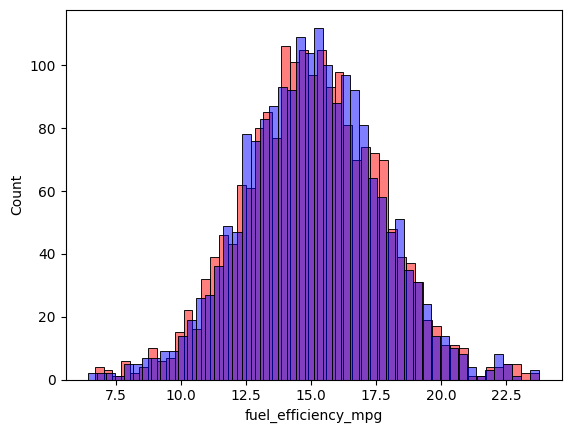

In [26]:
sns.histplot(y_val, color='red', bins=50, alpha=0.5)
sns.histplot(y_pred, color='blue', bins=50, alpha=0.5)

# Q4

In [27]:
df_train_copy = fix_hp_missing_values(df_train, 0)
df_train_copy

,engine_displacement,horsepower,vehicle_weight,model_year
0,220,144.0,2535.887591,2009
1,160,141.0,2741.170484,2019
2,230,155.0,2471.880237,2017
3,150,206.0,3748.164469,2015
4,300,111.0,2135.716359,2006
...,...,...,...,...
5819,260,139.0,2606.972984,2009
5820,280,132.0,4004.214323,2014
5821,210,152.0,2500.175687,2020
5822,250,154.0,2254.313245,2002


In [28]:
reg_val = [0, 0.01, 0.1, 1, 5, 10, 100]

In [29]:
def train_linear_regression_with_reg(X, y, r):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])
    XTX = np.dot(X.T, X)
    reg = r * np.eye(XTX.shape[0])
    XTX = XTX + reg
    XTX_inv = np.linalg.inv(XTX)
    w_full = np.dot(XTX_inv, X.T)
    w_full = np.dot(w_full, y)
    return w_full[0], w_full[1:]

In [30]:
df_train_copy = fix_hp_missing_values(df_train, 0)
df_train_copy = prepare_X(df_train_copy)

In [31]:
df_val_copy = fix_hp_missing_values(df_val, 0)
df_val_copy = prepare_X(df_val_copy)

for r in reg_val:
    w0, w = train_linear_regression_with_reg(df_train_copy, y_train, r)
    y_pred = w0 + np.dot(df_val_copy, w)
    rms = rmse(y_val, y_pred)
    print(f"R: {r}, RMSE: {rms}")

R: 0, RMSE: 0.52
R: 0.01, RMSE: 0.52
R: 0.1, RMSE: 0.52
R: 1, RMSE: 0.52
R: 5, RMSE: 0.52
R: 10, RMSE: 0.52
R: 100, RMSE: 0.52


# Q5

In [32]:
seed_values = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
rmse_scores = []

def rmse(y, y_pred):
    se = (y - y_pred) ** 2
    mse = se.mean()
    return np.sqrt(mse)

In [33]:
for seed in seed_values:
    df_train, df_val, df_test, y_train, y_test, y_val = prepare_dataset(df, seed, 'fuel_efficiency_mpg')
    df_train = fix_hp_missing_values(df_train, 0)
    df_val = fix_hp_missing_values(df_val, 0)
    df_train = prepare_X(df_train)
    w0, w = train_linear_regression(df_train, y_train)
    y_pred = w0 + np.dot(df_val, w)
    rmse_score = rmse(y_val, y_pred)
    rmse_scores.append(rmse_score)
    print(f"seed: {seed} rmse: {rmse_score}")
rmse_scores = np.array(rmse_scores)
std = round(np.std(rmse_scores), 3)
std

seed: 0 rmse: 0.5206531296294218
seed: 1 rmse: 0.521338891285577
seed: 2 rmse: 0.5228069974803171
seed: 3 rmse: 0.515951674119676
seed: 4 rmse: 0.5109129460053851
seed: 5 rmse: 0.52834064601107
seed: 6 rmse: 0.5313910658146311
seed: 7 rmse: 0.5090670387381733
seed: 8 rmse: 0.5147399129511132
seed: 9 rmse: 0.5131865908224594


np.float64(0.007)

# Q6

In [34]:
df_train, df_val, df_test, y_train, y_test, y_val = prepare_dataset(df, 9, 'fuel_efficiency_mpg')

In [35]:
df_train = pd.concat([df_train, df_val])
y_train = np.concatenate((y_train, y_val))

In [36]:
df_train = fix_hp_missing_values(df_train, 0)
df_test = fix_hp_missing_values(df_test, 0)


In [37]:
w0, w = train_linear_regression_with_reg(df_train, y_train, 0.001)
y_pred = w0 + np.dot(df_test, w)

In [38]:
round(rmse(y_pred, y_test), 3)

np.float64(0.516)